In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

In [3]:
# Load data
rv = pd.read_csv("rv_30stocks_2index.csv")

# Check structure
print(rv.head())

         Var1      rv_1      rv_2      rv_3      rv_4      rv_5      rv_6  \
0  05/07/2000  0.000065  0.001242  0.000419  0.000219  0.000728  0.000406   
1  06/07/2000  0.000054  0.001865  0.000224  0.000066  0.000660  0.000270   
2  07/07/2000  0.000038  0.001319  0.000336  0.000120  0.000490  0.000403   
3  10/07/2000  0.000034  0.002188  0.000369  0.000162  0.001440  0.000367   
4  11/07/2000  0.000080  0.001691  0.000149  0.000103  0.000972  0.000556   

       rv_7      rv_8      rv_9  ...     rv_23     rv_24     rv_25     rv_26  \
0  0.000242  0.000328  0.000246  ...  0.000163  0.000324  0.000518  0.000153   
1  0.000225  0.000338  0.000362  ...  0.000136  0.000293  0.000334  0.000183   
2  0.000215  0.000398  0.000247  ...  0.000170  0.000318  0.000445  0.000539   
3  0.000419  0.000228  0.000220  ...  0.000078  0.000413  0.000271  0.000152   
4  0.000297  0.000256  0.000383  ...  0.000248  0.000446  0.000511  0.000156   

      rv_27     rv_28     rv_29     rv_30     rv_31     

In [4]:

# Rename
rv = rv.rename(columns={"Var1": "Date"})

# Convert to datetime
rv["Date"] = pd.to_datetime(rv["Date"], dayfirst=True)

# Sort by date
rv = rv.sort_values("Date")

# Set as index
rv = rv.set_index("Date")

print(rv.index)

DatetimeIndex(['2000-07-05', '2000-07-06', '2000-07-07', '2000-07-10',
               '2000-07-11', '2000-07-12', '2000-07-13', '2000-07-14',
               '2000-07-17', '2000-07-18',
               ...
               '2025-07-17', '2025-07-18', '2025-07-21', '2025-07-22',
               '2025-07-23', '2025-07-24', '2025-07-25', '2025-07-28',
               '2025-07-29', '2025-07-30'],
              dtype='datetime64[ns]', name='Date', length=6205, freq=None)


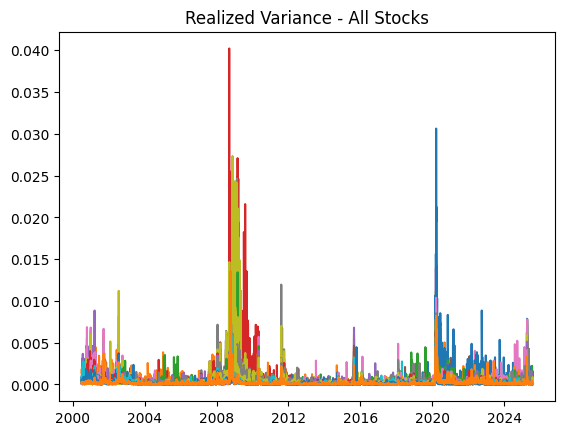

In [10]:

plt.figure()
for col in rv.columns:
    plt.plot(rv.index, rv[col])
plt.title("Realized Variance - All Stocks")
plt.show()

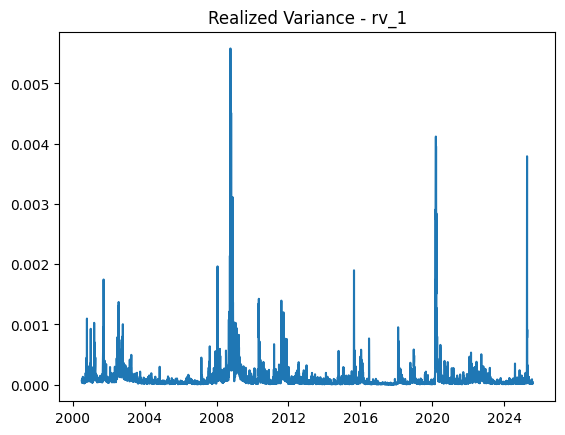

In [11]:
stock = rv.columns[0]

plt.figure()
plt.plot(rv.index, rv[stock])
plt.title(f"Realized Variance - {stock}")
plt.show()

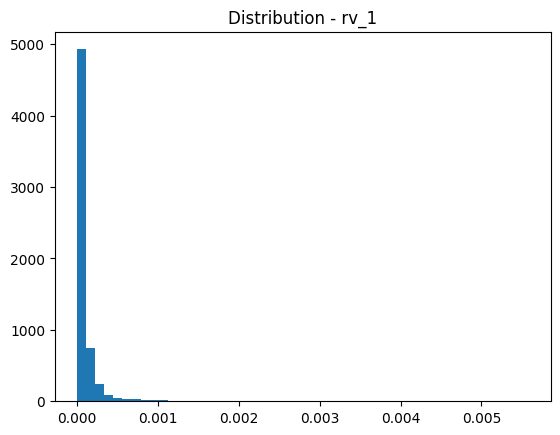

In [12]:
plt.figure()
plt.hist(rv[stock], bins=50)
plt.title(f"Distribution - {stock}")
plt.show()

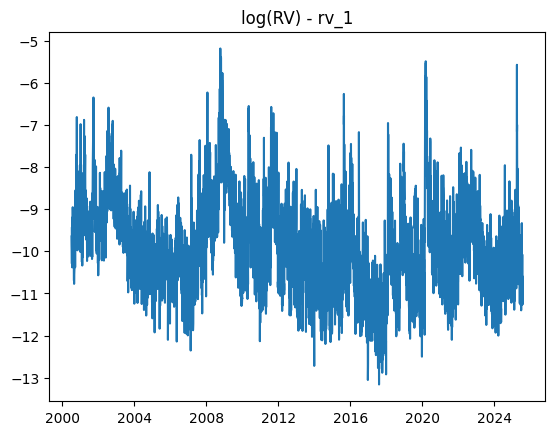

In [13]:
import numpy as np

plt.figure()
plt.plot(rv.index, np.log(rv[stock]))
plt.title(f"log(RV) - {stock}")
plt.show()

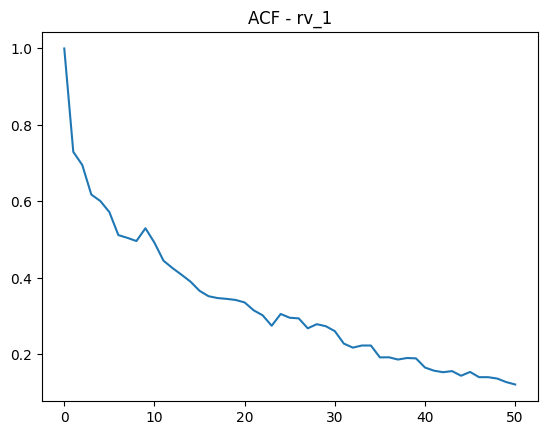

In [14]:
acf_vals = acf(rv[stock], nlags=50)

plt.figure()
plt.plot(acf_vals)
plt.title(f"ACF - {stock}")
plt.show()

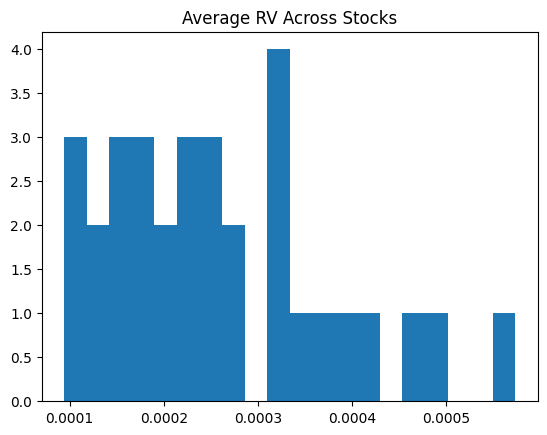

In [15]:
avg_rv = rv.mean()

plt.figure()
plt.hist(avg_rv, bins=20)
plt.title("Average RV Across Stocks")
plt.show()

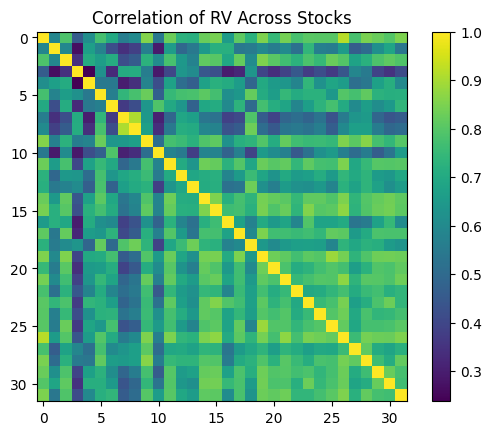

In [16]:
corr = rv.corr()

plt.figure()
plt.imshow(corr)
plt.title("Correlation of RV Across Stocks")
plt.colorbar()
plt.show()

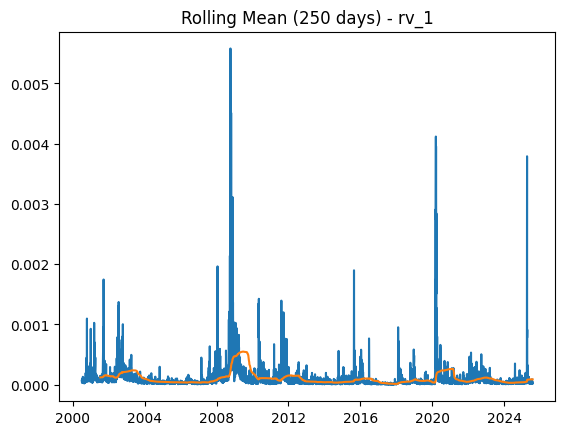

In [17]:
rolling_mean = rv[stock].rolling(250).mean()

plt.figure()
plt.plot(rv.index, rv[stock])
plt.plot(rv.index, rolling_mean)
plt.title(f"Rolling Mean (250 days) - {stock}")
plt.show()

In [19]:
stock = rv.columns[0]

print("Skew:", rv[stock].skew())
print("Kurtosis:", rv[stock].kurtosis())

Skew: 9.633923128839909
Kurtosis: 133.09220544593612


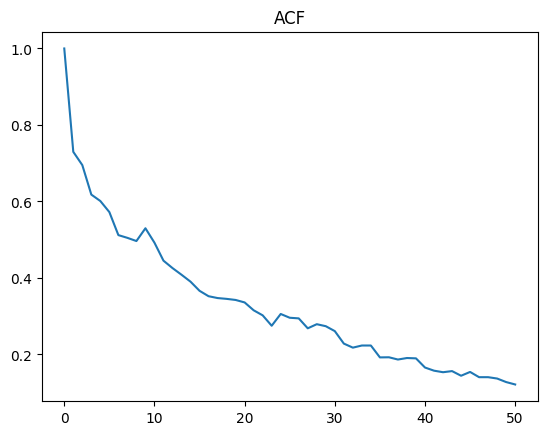

In [20]:

acf_vals = acf(rv[stock], nlags=50)

plt.figure()
plt.plot(acf_vals)
plt.title("ACF")
plt.show()

In [21]:
stock = rv.columns[0]
series = rv[stock].copy()

In [22]:
# Daily lag
RV_d = series.shift(1)

# Weekly average (last 5 days)
RV_w = series.rolling(5).mean().shift(1)

# Monthly average (last 22 days)
RV_m = series.rolling(22).mean().shift(1)

In [23]:
y = series

In [24]:
har_df = pd.DataFrame({
    "y": y,
    "RV_d": RV_d,
    "RV_w": RV_w,
    "RV_m": RV_m
})

# Drop missing values (due to rolling windows)
har_df = har_df.dropna()

print(har_df.head())
print(har_df.shape)

                   y      RV_d      RV_w      RV_m
Date                                              
2000-08-04  0.000065  0.000088  0.000074  0.000062
2000-08-07  0.000044  0.000065  0.000064  0.000062
2000-08-08  0.000041  0.000044  0.000062  0.000061
2000-08-09  0.000048  0.000041  0.000058  0.000062
2000-08-10  0.000042  0.000048  0.000057  0.000062
(6183, 4)


In [25]:
import statsmodels.api as sm

X = har_df[["RV_d", "RV_w", "RV_m"]]
X = sm.add_constant(X)

y = har_df["y"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                     2981.
Date:                Thu, 12 Feb 2026   Prob (F-statistic):               0.00
Time:                        00:14:31   Log-Likelihood:                 45455.
No. Observations:                6183   AIC:                        -9.090e+04
Df Residuals:                    6179   BIC:                        -9.088e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.079e-05   2.28e-06      4.731      0.0